# Import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import make_column_transformer, ColumnTransformer 
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV

In [2]:
#Loading datasets

df_train= pd.read_csv("train.csv")
df_test=pd.read_csv("test.csv")

# Exploring the data and understand it

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
#Already we can see from the data that the mean age for the titanic was 30 and the oldest was 80.
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363


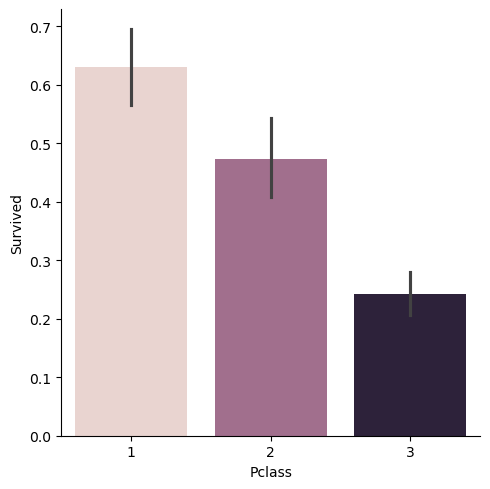

In [6]:
#Survivability rate by passanger class.
# From this we can say that the higher the class, higher the chance to survive
print(df_train.groupby(['Pclass'], as_index=False)['Survived'].mean())
sns.catplot(x = 'Pclass', y = 'Survived', data=df_train, kind='bar', hue = 'Pclass', legend=False)

      Sex  Survived
0  female  0.742038
1    male  0.188908


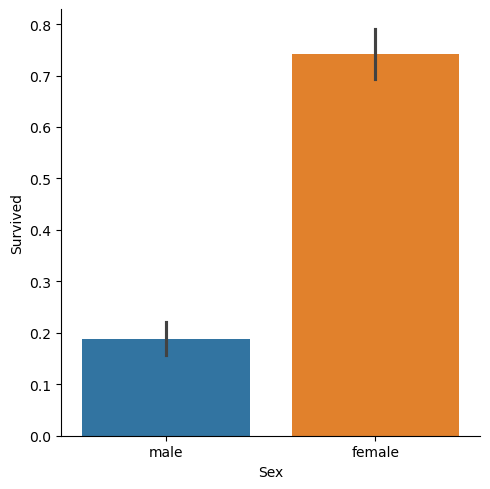

In [7]:
#Survivability rate by sex of the passenger.
# Its clearly depicted in here that female's had more chances of survival than the man passengers
print(df_train.groupby(['Sex'], as_index=False)['Survived'].mean())
sns.catplot(x = 'Sex', y = 'Survived', data=df_train, kind='bar', hue = 'Sex', legend=False)

   SibSp  Survived
0      0  0.345395
1      1  0.535885
2      2  0.464286
3      3  0.250000
4      4  0.166667
5      5  0.000000
6      8  0.000000


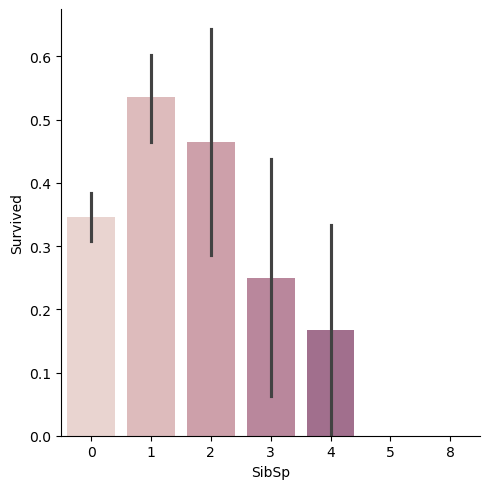

In [8]:
#Survivability rate by siblings/spouse.
# Having 0 siblings/spouse had more chances to survive than the passengers that had atleast 3.
# The people that had 1 passenger had the most chances to survive.
print(df_train.groupby(['SibSp'], as_index=False)['Survived'].mean())
sns.catplot(x = 'SibSp', y = 'Survived', data=df_train, kind='bar', hue = 'SibSp', legend=False)

   Parch  Survived
0      0  0.343658
1      1  0.550847
2      2  0.500000
3      3  0.600000
4      4  0.000000
5      5  0.200000
6      6  0.000000


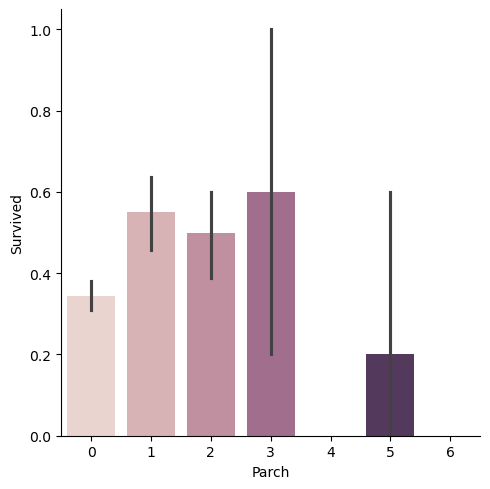

In [9]:
#Survivabilty rate by parents/childs.
# Passenger that had 0 or atleast 4 parents/child had fewer chances to survive than the rest.
print(df_train.groupby(['Parch'], as_index=False)['Survived'].mean())
sns.catplot(x = 'Parch', y = 'Survived', data=df_train, kind='bar', hue = 'Parch', legend=False)

In [10]:
#So we can see the family size more clear, we are going to put together sibsp and parch.
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1 #Plus 1 to count yourself in.
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1

   FamilySize  Survived
0           1  0.303538
1           2  0.552795
2           3  0.578431
3           4  0.724138
4           5  0.200000
5           6  0.136364
6           7  0.333333
7           8  0.000000
8          11  0.000000


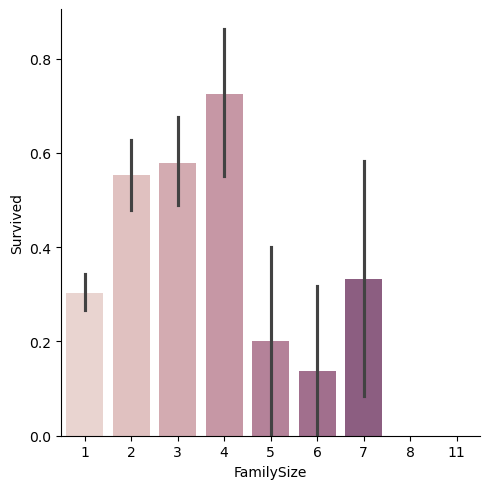

In [11]:
#Survivabilty rate by Family Size.
# The families that were composed between 2 and 4 passenger, had the most chances to survive overall.
# More than 4 passengers in the family, lowers the survivability rate drastically.
print(df_train.groupby(['FamilySize'], as_index=False)['Survived'].mean())
sns.catplot(x = 'FamilySize', y = 'Survived', data=df_train, kind='bar', hue = 'FamilySize', legend=False)

In [12]:
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
df_train['Family_Size_Grouped'] = df_train['FamilySize'].map(family_map)
df_test['Family_Size_Grouped'] = df_test['FamilySize'].map(family_map)

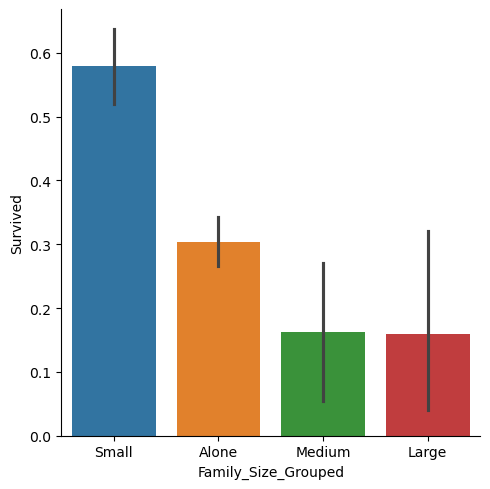

In [13]:
df_train.groupby(['Family_Size_Grouped'], as_index=False)['Survived'].mean()
sns.catplot(x = 'Family_Size_Grouped', y = 'Survived', data=df_train, kind='bar', hue = 'Family_Size_Grouped', legend=False)

  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.336957


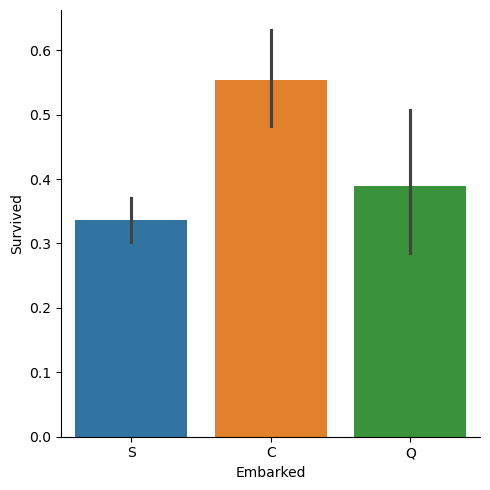

In [14]:
#Survivability by port wich passenger embarked. C = Cherbourg, Q = Queenstown, S = Southampton
# Most of the people that could survive, embarked from Cherbourg and the least were from Southampton.
print(df_train.groupby(['Embarked'], as_index=False)['Survived'].mean())
sns.catplot(x = 'Embarked', y = 'Survived', data=df_train, kind='bar', hue = 'Embarked', legend=False)

Survived
0    549
1    342
Name: count, dtype: int64


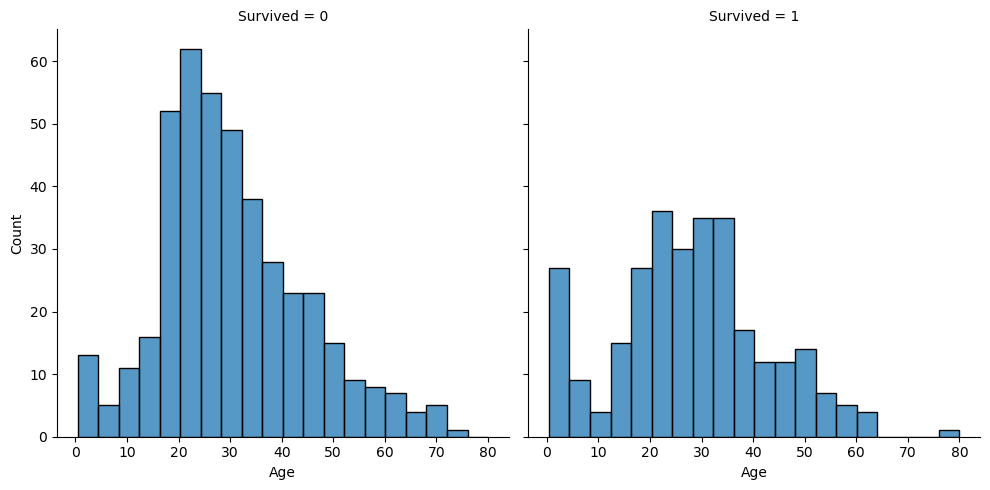

In [15]:
#Survivability rate by age.
# Most of the people didnt survive, having (most of them) around 20-30 years old.
# Meantime the passengers that survive had a more even groups of age. 
# Kids below 5 years old had more chances of survival than older ones.
print(df_train['Survived'].value_counts())
sns.displot(df_train, x = 'Age', col = 'Survived')

## Organizing the age groups

In [16]:
df_train['Age_Cut'] = pd.qcut(df_train['Age'], 8)
df_test['Age_Cut'] = pd.qcut(df_test['Age'], 8)

In [17]:
df_train.groupby(['Age_Cut'], as_index=False)['Survived'].mean()

,Age_Cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


In [18]:
df_train.loc[df_train['Age'] <= 16, 'Age'] = 0
df_train.loc[(df_train['Age'] > 16) & (df_train['Age'] <= 20), 'Age'] = 1
df_train.loc[(df_train['Age'] > 20) & (df_train['Age'] <= 24), 'Age'] = 2
df_train.loc[(df_train['Age'] > 24) & (df_train['Age'] <= 28), 'Age'] = 3
df_train.loc[(df_train['Age'] > 28) & (df_train['Age'] <= 32.312), 'Age'] = 4
df_train.loc[(df_train['Age'] > 32.312) & (df_train['Age'] <= 38), 'Age'] = 5
df_train.loc[(df_train['Age'] > 38) & (df_train['Age'] <= 47), 'Age'] = 6
df_train.loc[(df_train['Age'] > 47) & (df_train['Age'] <= 80), 'Age'] = 7
df_train.loc[df_train['Age'] > 80, 'Age'] 

df_test.loc[df_test['Age'] <= 16, 'Age'] = 0
df_test.loc[(df_test['Age'] > 16) & (df_test['Age'] <= 20), 'Age'] = 1
df_test.loc[(df_test['Age'] > 20) & (df_test['Age'] <= 24), 'Age'] = 2
df_test.loc[(df_test['Age'] > 24) & (df_test['Age'] <= 28), 'Age'] = 3
df_test.loc[(df_test['Age'] > 28) & (df_test['Age'] <= 32.312), 'Age'] = 4
df_test.loc[(df_test['Age'] > 32.312) & (df_test['Age'] <= 38), 'Age'] = 5
df_test.loc[(df_test['Age'] > 38) & (df_test['Age'] <= 47), 'Age'] = 6
df_test.loc[(df_test['Age'] > 47) & (df_test['Age'] <= 80), 'Age'] = 7
df_test.loc[df_test['Age'] > 80, 'Age']

Series([], Name: Age, dtype: float64)

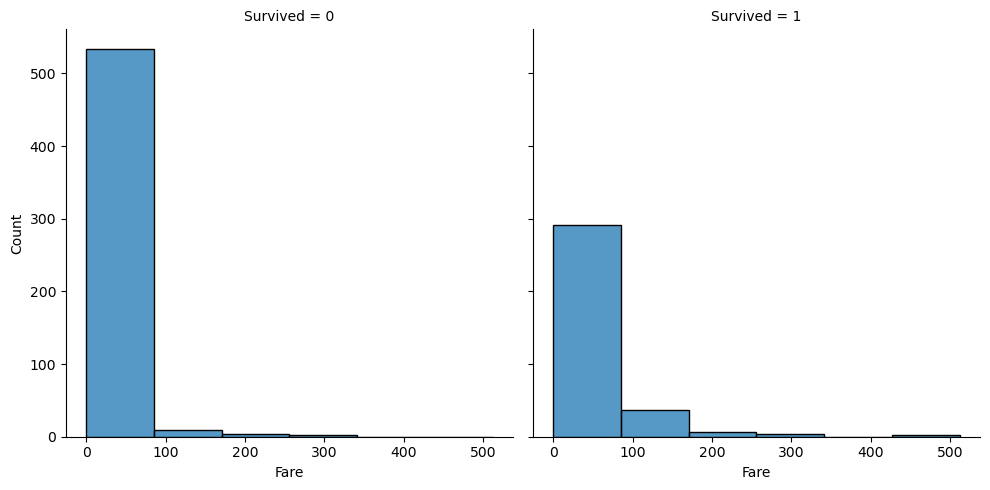

In [19]:
sns.displot(df_train, x='Fare', col='Survived', binwidth=80, height=5)

## Organizing Fare prices

In [20]:
df_train['Fare_Cut'] = pd.qcut(df_train['Fare'], 6)
df_test['Fare_Cut'] = pd.qcut(df_test['Fare'], 6)

In [21]:
df_train.groupby(['Fare_Cut'], as_index=False)['Survived'].mean()

,Fare_Cut,Survived
0,"(-0.001, 7.775]",0.205128
1,"(7.775, 8.662]",0.190789
2,"(8.662, 14.454]",0.366906
3,"(14.454, 26.0]",0.436242
4,"(26.0, 52.369]",0.417808
5,"(52.369, 512.329]",0.697987


In [22]:
df_train.loc[df_train['Fare'] <= 7.775, 'Fare'] = 0
df_train.loc[(df_train['Fare'] > 7.775) & (df_train['Fare'] <= 8.662), 'Fare'] = 1
df_train.loc[(df_train['Fare'] > 8.662) & (df_train['Fare'] <= 14.454), 'Fare'] = 2
df_train.loc[(df_train['Fare'] > 14.454) & (df_train['Fare'] <= 26), 'Fare'] = 3
df_train.loc[(df_train['Fare'] > 26) & (df_train['Fare'] <= 52.369), 'Fare'] = 4
df_train.loc[(df_train['Fare'] > 52.369) & (df_train['Fare'] <= 512.329), 'Fare'] = 5
df_train.loc[df_train['Fare'] > 512.329, 'Fare'] 

df_test.loc[df_test['Fare'] <= 7.775, 'Fare'] = 0
df_test.loc[(df_test['Fare'] > 7.775) & (df_test['Fare'] <= 8.662), 'Fare'] = 1
df_test.loc[(df_test['Fare'] > 8.662) & (df_test['Fare'] <= 14.454), 'Fare'] = 2
df_test.loc[(df_test['Fare'] > 14.454) & (df_test['Fare'] <= 26), 'Fare'] = 3
df_test.loc[(df_test['Fare'] > 26) & (df_test['Fare'] <= 52.369), 'Fare'] = 4
df_test.loc[(df_test['Fare'] > 52.369) & (df_test['Fare'] <= 512.329), 'Fare'] = 5
df_test.loc[df_test['Fare'] > 512.329, 'Fare']

343    512.3292
Name: Fare, dtype: float64

## Orginizing Names

In [23]:
df_train['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [24]:
df_train['Title'] = df_train['Name'].str.split(pat= ",", expand=True)[1].str.split(pat= ".", expand=True)[0].apply(lambda x: x.strip())
df_test['Title'] = df_test['Name'].str.split(pat= ",", expand=True)[1].str.split(pat= ".", expand=True)[0].apply(lambda x: x.strip())

In [25]:
df_train.groupby(['Title'], as_index=False)['Survived'].mean()

,Title,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


In [26]:
#military - Capt, Col, Major
#noble - Jonkheer, the Countess, Don, Lady, Sir
#unmaried Female - Mlle, Ms, Mme

df_train['Title'] = df_train['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Jonkheer': 'Noble',
    'the Countess': 'Noble',
    'Don': 'Noble',
    'Lady': 'Noble',
    'Sir': 'Noble',
    'Mlle': 'Noble',
    'Ms': 'Noble',
    'Mme': 'Noble'
})

df_test['Title'] = df_test['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Jonkheer': 'Noble',
    'the Countess': 'Noble',
    'Don': 'Noble',
    'Lady': 'Noble',
    'Sir': 'Noble',
    'Mlle': 'Noble',
    'Ms': 'Noble',
    'Mme': 'Noble'
})

In [27]:
df_train.groupby(['Title'], as_index=False)['Survived'].agg(['count', 'mean'])

,Title,count,mean
0,Dr,7,0.428571
1,Master,40,0.575000
2,Military,5,0.400000
3,Miss,182,0.697802
4,Mr,517,0.156673
5,Mrs,125,0.792000
6,Noble,9,0.777778
7,Rev,6,0.000000


In [28]:
df_train['Name_Length'] = df_train['Name'].apply(lambda x: len(x))
df_test['Name_Length'] = df_test['Name'].apply(lambda x: len(x))

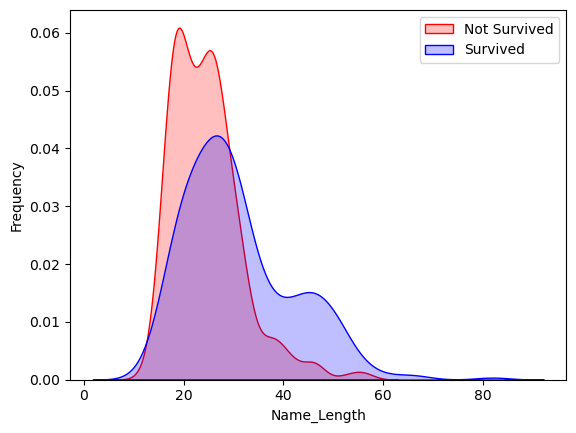

In [29]:
g = sns.kdeplot(df_train['Name_Length'][(df_train['Survived']==0) & (df_train['Name_Length'].notnull())], color='Red', fill=True)
g = sns.kdeplot(df_train['Name_Length'][(df_train['Survived']==1) & (df_train['Name_Length'].notnull())], ax=g, color='Blue', fill=True)
g.set_xlabel('Name_Length')
g.set_ylabel('Frequency')
g = g.legend(['Not Survived', 'Survived'])

In [30]:
df_train['Name_LengthGB'] = pd.qcut(df_train['Name_Length'], 8)
df_test['Name_LengthGB'] = pd.qcut(df_test['Name_Length'], 8)

In [31]:
df_train.groupby(['Name_LengthGB'], as_index=False)['Survived'].mean()

,Name_LengthGB,Survived
0,"(11.999, 18.0]",0.214286
1,"(18.0, 20.0]",0.252427
2,"(20.0, 23.0]",0.307692
3,"(23.0, 25.0]",0.346939
4,"(25.0, 27.25]",0.292929
5,"(27.25, 30.0]",0.428571
6,"(30.0, 38.0]",0.517241
7,"(38.0, 82.0]",0.745283


In [32]:
df_train.loc[df_train['Name_Length'] <= 18, 'Name_Size'] = 0
df_train.loc[(df_train['Name_Length'] > 18) & (df_train['Name_Length'] <= 20), 'Name_Size'] = 1
df_train.loc[(df_train['Name_Length'] > 20) & (df_train['Name_Length'] <= 23), 'Name_Size'] = 2
df_train.loc[(df_train['Name_Length'] > 23) & (df_train['Name_Length'] <= 25), 'Name_Size'] = 3
df_train.loc[(df_train['Name_Length'] > 25) & (df_train['Name_Length'] <= 27.25), 'Name_Size'] = 4
df_train.loc[(df_train['Name_Length'] > 27.25) & (df_train['Name_Length'] <= 30), 'Name_Size'] = 5
df_train.loc[(df_train['Name_Length'] > 30) & (df_train['Name_Length'] <= 38), 'Name_Size'] = 6
df_train.loc[(df_train['Name_Length'] > 38) & (df_train['Name_Length'] <= 82), 'Name_Size'] = 7
df_train.loc[df_train['Name_Length'] > 82, 'Name_Size']

df_test.loc[df_test['Name_Length'] <= 22, 'Name_Size'] = 0
df_test.loc[(df_test['Name_Length'] > 18) & (df_test['Name_Length'] <= 20), 'Name_Size'] = 1
df_test.loc[(df_test['Name_Length'] > 20) & (df_test['Name_Length'] <= 23), 'Name_Size'] = 2
df_test.loc[(df_test['Name_Length'] > 23) & (df_test['Name_Length'] <= 25), 'Name_Size'] = 3
df_test.loc[(df_test['Name_Length'] > 25) & (df_test['Name_Length'] <= 27.25), 'Name_Size'] = 4
df_test.loc[(df_test['Name_Length'] > 27.25) & (df_test['Name_Length'] <= 30), 'Name_Size'] = 5
df_test.loc[(df_test['Name_Length'] > 30) & (df_test['Name_Length'] <= 38), 'Name_Size'] = 6
df_test.loc[(df_test['Name_Length'] > 38) & (df_test['Name_Length'] <= 82), 'Name_Size'] = 7
df_test.loc[df_test['Name_Length'] > 82, 'Name_Size']

Series([], Name: Name_Size, dtype: float64)

## Organizing Tickets

In [33]:
df_train['Ticket']

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: str

In [34]:
df_train['TicketNumber'] = df_train['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))
df_test['TicketNumber'] = df_test['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))

In [35]:
df_train.groupby(['TicketNumber'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values('count', ascending=False)

,TicketNumber,count,mean
196,2343,7,0.000000
464,347082,7,0.000000
94,1601,7,0.714286
168,2144,6,0.000000
468,347088,6,0.000000
...,...,...,...
674,8475,1,0.000000
675,851,1,0.000000
676,9234,1,1.000000
63,11769,1,1.000000


In [36]:
df_train.groupby('TicketNumber')['TicketNumber'].transform('count')

0      1
1      1
2      1
3      2
4      1
      ..
886    1
887    1
888    2
889    1
890    1
Name: TicketNumber, Length: 891, dtype: int64

In [37]:
df_train['TicketNumberCounts'] = df_train.groupby('TicketNumber')['TicketNumber'].transform('count')
df_test['TicketNumberCounts'] = df_test.groupby('TicketNumber')['TicketNumber'].transform('count')

In [38]:
df_train.groupby(['TicketNumberCounts'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values('count', ascending=False)

,TicketNumberCounts,count,mean
0,1,544,0.295956
1,2,188,0.569149
2,3,66,0.712121
3,4,44,0.500000
6,7,21,0.238095
5,6,18,0.000000
4,5,10,0.000000


In [39]:
df_train['Ticket'].str.split(pat=" ", expand=True)

,0,1,2
0,A/5,21171,NaN
1,PC,17599,NaN
2,STON/O2.,3101282,NaN
3,113803,NaN,NaN
4,373450,NaN,NaN
...,...,...,...
886,211536,NaN,NaN
887,112053,NaN,NaN
888,W./C.,6607,NaN
889,111369,NaN,NaN


In [40]:
df_train['TicketLocation'] = np.where(df_train['Ticket'].str.split(pat=" ", expand=True)[1].notna(), df_train['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x: x.strip()), 'Blank')
df_test['TicketLocation'] = np.where(df_test['Ticket'].str.split(pat=" ", expand=True)[1].notna(), df_test['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x: x.strip()), 'Blank')

In [41]:
df_train['TicketLocation'].value_counts()

TicketLocation
Blank         665
PC             60
C.A.           27
STON/O         12
A/5            10
W./C.           9
SOTON/O.Q.      8
CA.             8
A/5.            7
SOTON/OQ        7
STON/O2.        6
CA              6
S.O.C.          5
C               5
SC/PARIS        5
F.C.C.          5
SC/Paris        4
PP              3
A/4.            3
SC/AH           3
A/4             3
S.O./P.P.       3
A./5.           2
A.5.            2
P/PP            2
WE/P            2
SOTON/O2        2
S.C./PARIS      2
S.C./A.4.       1
S.P.            1
SO/C            1
W.E.P.          1
A4.             1
S.O.P.          1
Fa              1
W/C             1
SW/PP           1
SCO/W           1
SC              1
A/S             1
S.W./PP         1
F.C.            1
C.A./SOTON      1
Name: count, dtype: int64

In [42]:
df_train['TicketLocation'] = df_train['TicketLocation'].replace({
    'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})

df_test['TicketLocation'] = df_test['TicketLocation'].replace({
    'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})

In [43]:
df_train.groupby(['TicketLocation'], as_index=False)['Survived'].agg(['count', 'mean'])

,TicketLocation,count,mean
0,A/4,6,0.000000
1,A/5,21,0.095238
2,A/S,1,0.000000
3,A4.,1,0.000000
4,Blank,665,0.383459
5,C,5,0.400000
6,C.A./SOTON,1,0.000000
7,CA,41,0.341463
8,F.C.,1,0.000000
9,F.C.C.,5,0.800000


## Fixing Variables with Null values

In [44]:
df_train.isnull().sum()

PassengerId              0
Survived                 0
Pclass                   0
Name                     0
Sex                      0
Age                    177
SibSp                    0
Parch                    0
Ticket                   0
Fare                     0
Cabin                  687
Embarked                 2
FamilySize               0
Family_Size_Grouped      0
Age_Cut                177
Fare_Cut                 0
Title                    0
Name_Length              0
Name_LengthGB            0
Name_Size                0
TicketNumber             0
TicketNumberCounts       0
TicketLocation           0
dtype: int64

In [45]:
#Filling both test and train DataFrames with U, so we can get a value.
df_train['Cabin'] = df_train['Cabin'].fillna('U')
df_train['Cabin'] = pd.Series([i[0] if not pd.isnull(i) else 'x' for i in df_train['Cabin']])

df_test['Cabin'] = df_test['Cabin'].fillna('U')
df_test['Cabin'] = pd.Series([i[0] if not pd.isnull(i) else 'x' for i in df_test['Cabin']])

In [46]:
# 687 people didnt have a cabin assign to them, maybe this could have been people from the 3rd class that just went to whatever cabin
# and decided it was theirs. 
df_train.groupby(['Cabin'], as_index=False)['Survived'].agg(['count', 'mean'])

,Cabin,count,mean
0,A,15,0.466667
1,B,47,0.744681
2,C,59,0.593220
3,D,33,0.757576
4,E,32,0.750000
5,F,13,0.615385
6,G,4,0.500000
7,T,1,0.000000
8,U,687,0.299854


In [47]:
#Applies 0 to passengers that have 0, and 1 to everyone else
df_train['Cabin_Assigned'] = df_train['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)
df_test['Cabin_Assigned'] = df_test['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)

In [48]:
df_train.groupby(['Cabin_Assigned'], as_index=False)['Survived'].agg(['count', 'mean'])

,Cabin_Assigned,count,mean
0,0,687,0.299854
1,1,204,0.666667


In [49]:
#Checking if evry value on cabin changed
df_train.isnull().sum()

PassengerId              0
Survived                 0
Pclass                   0
Name                     0
Sex                      0
Age                    177
SibSp                    0
Parch                    0
Ticket                   0
Fare                     0
Cabin                    0
Embarked                 2
FamilySize               0
Family_Size_Grouped      0
Age_Cut                177
Fare_Cut                 0
Title                    0
Name_Length              0
Name_LengthGB            0
Name_Size                0
TicketNumber             0
TicketNumberCounts       0
TicketLocation           0
Cabin_Assigned           0
dtype: int64

In [50]:
#Making a value cointaining mean ages for both test and train DataFrames
mean_ages_train = df_train.groupby('Sex')['Age'].mean() 
mean_ages_test = df_test.groupby('Sex')['Age'].mean() 

print(mean_ages_train)
print(mean_ages_test)

Sex
female    3.222222
male      3.600442
Name: Age, dtype: float64
Sex
female    3.456693
male      3.580488
Name: Age, dtype: float64


PassengerId              0
Survived                 0
Pclass                   0
Name                     0
Sex                      0
Age                      0
SibSp                    0
Parch                    0
Ticket                   0
Fare                     0
Cabin                    0
Embarked                 2
FamilySize               0
Family_Size_Grouped      0
Age_Cut                177
Fare_Cut                 0
Title                    0
Name_Length              0
Name_LengthGB            0
Name_Size                0
TicketNumber             0
TicketNumberCounts       0
TicketLocation           0
Cabin_Assigned           0
dtype: int64

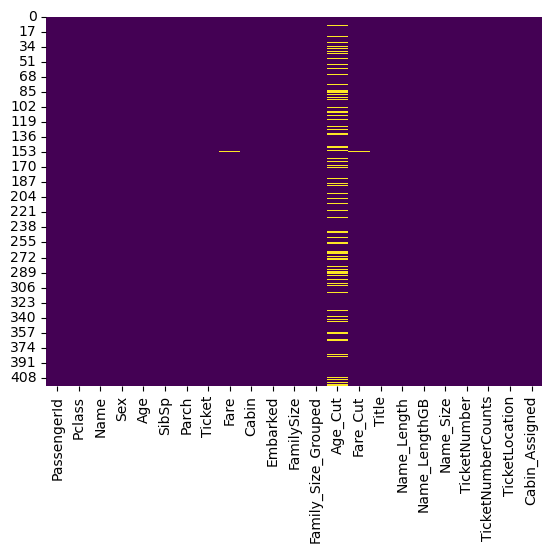

In [51]:
#Filling NaN values with the mean ages 
df_train['Age'] = df_train.apply(
    lambda row: mean_ages_train[row['Sex']] 
    if pd.isnull(row['Age']) 
    else row['Age'],
    axis=1
)
    
df_test['Age'] = df_test.apply(
    lambda row: mean_ages_test[row['Sex']] 
    if pd.isnull(row['Age']) 
    else row['Age'],
    axis=1
)

#Heat_map
sns.heatmap(df_train.isnull(),cmap = 'viridis', cbar = False)
sns.heatmap(df_test.isnull(),cmap = 'viridis', cbar = False)

df_train.isnull().sum()

# ML models for Titanic

In [52]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   PassengerId          418 non-null    int64   
 1   Pclass               418 non-null    int64   
 2   Name                 418 non-null    str     
 3   Sex                  418 non-null    str     
 4   Age                  418 non-null    float64 
 5   SibSp                418 non-null    int64   
 6   Parch                418 non-null    int64   
 7   Ticket               418 non-null    str     
 8   Fare                 417 non-null    float64 
 9   Cabin                418 non-null    str     
 10  Embarked             418 non-null    str     
 11  FamilySize           418 non-null    int64   
 12  Family_Size_Grouped  418 non-null    str     
 13  Age_Cut              332 non-null    category
 14  Fare_Cut             417 non-null    category
 15  Title                418 non-null 

In [53]:
ohe = OneHotEncoder(sparse_output=False)
ode = OrdinalEncoder
SI = SimpleImputer(strategy='most_frequent')

In [54]:
ode_cols = ['Family_Size_Grouped']
ohe_cols = ['Sex', 'Embarked']

In [55]:
X = df_train.drop(['Survived'], axis=1)
y = df_train['Survived']

X_test = df_test.drop(['Age_Cut', 'Fare_Cut'], axis=1)

In [56]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=20)

In [57]:
ordinal_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])


In [58]:
ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [59]:
col_trans = ColumnTransformer(transformers = [
    ('impute', SI, ['Age']),
    ('ord_pipeline', ordinal_pipeline, ode_cols),
    ('ohe_pipeline', ohe_pipeline, ohe_cols),
    ('passthrough', 'passthrough', ['Pclass', 'TicketNumberCounts', 'Cabin_Assigned', 'Name_Size', 'Fare'])
    ],
    remainder = 'drop',
    n_jobs=-1
)

In [60]:
rfc = RandomForestClassifier()

In [61]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'min_samples_split': [5, 10, 15],
    'max_depth': [8, 9, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

In [62]:
CV_rfc = GridSearchCV(estimator=rfc, param_grid= param_grid, cv=StratifiedKFold(n_splits=5))

In [63]:
pipefinalrfc = make_pipeline(col_trans, CV_rfc)
pipefinalrfc.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [64]:
print(CV_rfc.best_params_)
print(CV_rfc.best_score_)

{'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
0.821619225844578


In [65]:
dtc = DecisionTreeClassifier()

In [66]:
param_grid = {
    'min_samples_split': [5, 10, 15],
    'max_depth': [10,20,30],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

In [67]:
CV_dtc = GridSearchCV(estimator=dtc, param_grid= param_grid, cv=StratifiedKFold(n_splits=5))

In [68]:
pipefinaldtc = make_pipeline(col_trans, CV_dtc)
pipefinaldtc.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [69]:
print(CV_dtc.best_params_)
print(CV_dtc.best_score_)

{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 15}
0.8075839653304442


In [70]:
knn = KNeighborsClassifier()

In [71]:
param_grid = {
    'n_neighbors':[3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1,2]
}

In [72]:
CV_knn = GridSearchCV(estimator=knn, param_grid= param_grid, cv=StratifiedKFold(n_splits=5))

In [73]:
pipefinalknn = make_pipeline(col_trans, CV_knn)
pipefinalknn.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [74]:
svc = SVC()

In [75]:
param_grid = {
    'C': [100, 10, 1.0, 0.1, 0.001, 0.001],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

In [76]:
CV_svc = GridSearchCV(estimator=svc, param_grid= param_grid, cv=StratifiedKFold(n_splits=5))

In [77]:
pipefinalsvc = make_pipeline(col_trans, CV_svc)
pipefinalsvc.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [78]:
lr = LogisticRegression()

In [79]:
param_grid = {
    'C': [100, 10, 1.0, 0.1, 0.001, 0.001]
}

In [80]:
CV_lr = GridSearchCV(estimator=lr, param_grid= param_grid, cv=StratifiedKFold(n_splits=5))

In [100]:
pipefinallr = make_pipeline(col_trans, CV_lr)
pipefinallr.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [82]:
gnb = GaussianNB()

In [83]:
param_grid = {
    'var_smoothing': [0.00000001,0.000000001,0.00000001]
}

In [84]:
CV_gnb = GridSearchCV(estimator=gnb, param_grid= param_grid, cv=StratifiedKFold(n_splits=5))

In [85]:
pipefinalgnb = make_pipeline(col_trans, CV_gnb)
pipefinalgnb.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [98]:
#I had to do this line of code because of ONE SINGLE missing value....
X_test['Fare'] = X_test['Fare'].fillna(X_test['Fare'].mean())

In [101]:
Y_pred = pipefinalrfc.predict(X_test)
Y_pred2 = pipefinaldtc.predict(X_test)
Y_pred3 = pipefinalknn.predict(X_test)
Y_pred4 = pipefinalsvc.predict(X_test)
Y_pred5 = pipefinallr.predict(X_test)
Y_pred6 = pipefinalgnb.predict(X_test)

In [104]:
predict_rfc = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': Y_pred
})

predict_dtc = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': Y_pred2
})

predict_knn = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': Y_pred3
})

predict_svc = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': Y_pred4
})

predict_lr = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': Y_pred5
})

predict_gnb = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': Y_pred6
})

In [106]:
predict_rfc.to_csv('submissionTitanic_rfc.csv', index=False)
predict_dtc.to_csv('submissionTitanic_dtc.csv', index=False)
predict_knn.to_csv('submissionTitanic_knn.csv', index=False)
predict_svc.to_csv('submissionTitanic_svc.csv', index=False)
predict_lr.to_csv('submissionTitanic_lr.csv', index=False)
predict_gnb.to_csv('submissionTitanic_gnb.csv', index=False)

# Conclusion

- According to the Titanic competition on Kaggle, the best model (in this case) was DecisionTreeClassifier with a score of 0.78468. This result can improve with a different model, and maybe with different parameters.
- This disaster shows how people could behave in a moment of crisis. Middle age women and kids had the most survival rate out of all.
- Men in general (except kids) had the highest mortality rate.